# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [ ]:
!kaggle datasets download -d himanshunakrani/iris-dataset
!unzip -q iris-dataset.zip -d dataset

print("✅ Dataset berhasil didownload dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
License(s): CC0-1.0
100% 0.98k/0.98k [00:00<00:00, 2.81MB/s]

✅ Dataset berhasil didownload dan diekstrak!


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
#Type your code here

# Load dataset
df = pd.read_csv('dataset/iris.csv')

# Tampilkan informasi awal
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nHead:")
df.head()
print("\nDescribe:")
df.describe()

Shape: (150, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Head:

Describe:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing: 0

Jumlah duplikat: 3

Distribusi target:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


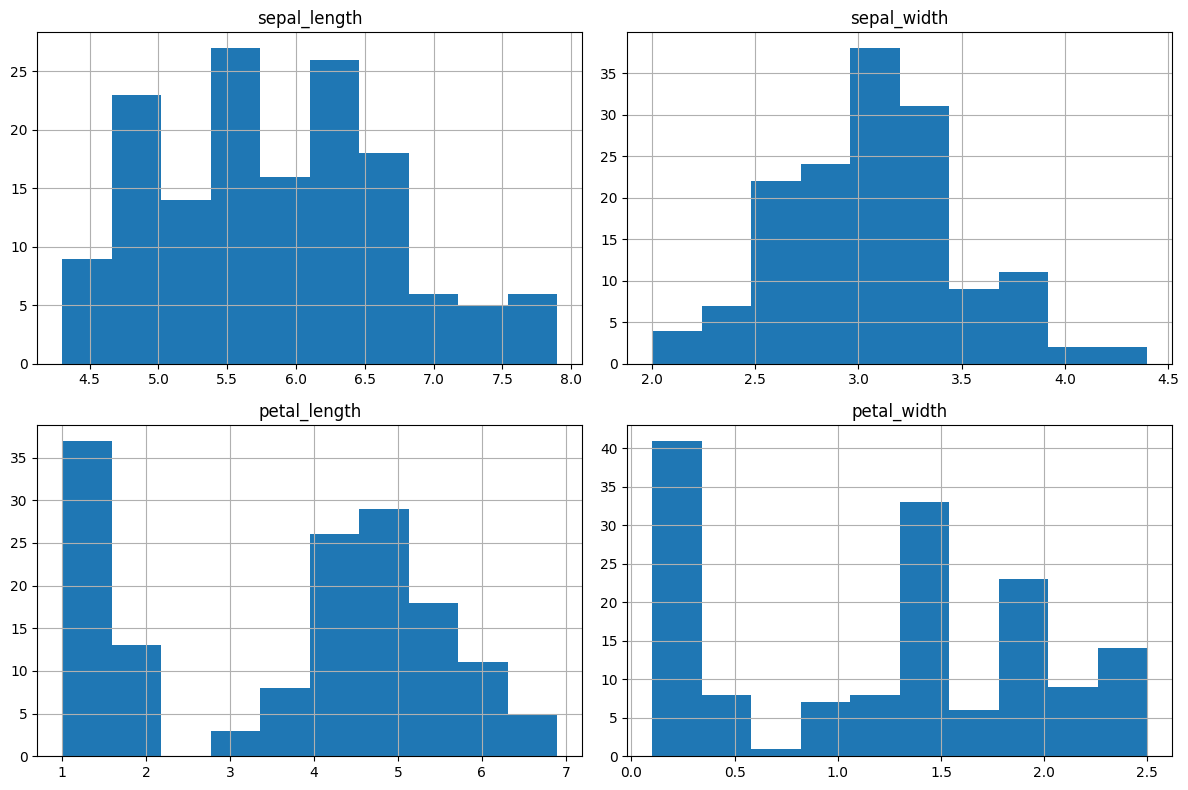

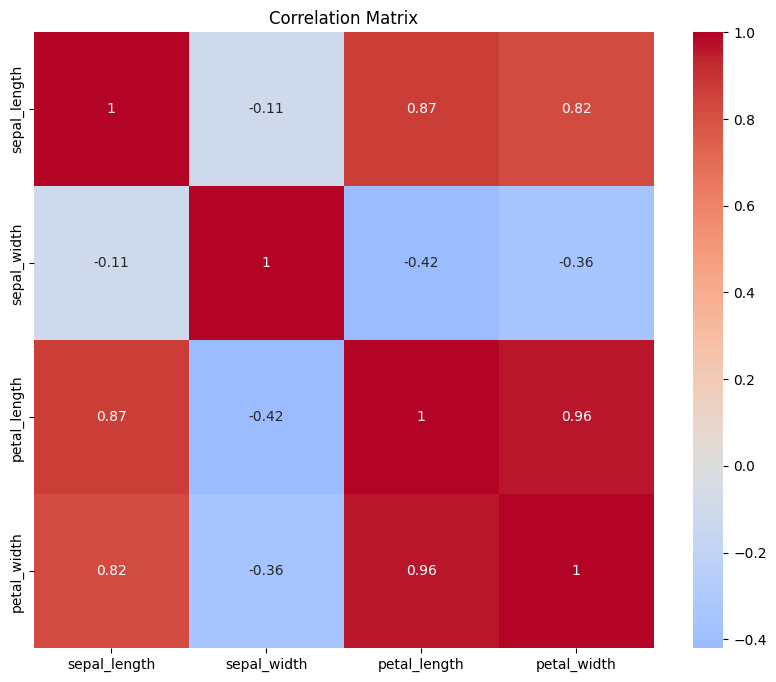

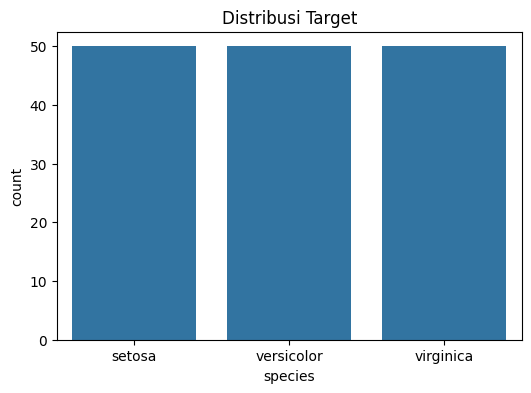

In [9]:
#Type your code here
# ===== Cek Missing Values =====
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# ===== Cek Duplikat =====
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

# ===== Distribusi Target =====
print("\nDistribusi target:")
print(df['species'].value_counts())

# ===== Visualisasi =====
# Histogram semua fitur numerik
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Countplot untuk kolom target (jika klasifikasi)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species')
plt.title('Distribusi Target')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# ===== Handle Missing Values =====
# Opsi 1: Hapus baris yang missing
df = df.dropna()
# Opsi 2: Isi dengan mean/median
# df['kolom'] = df['kolom'].fillna(df['kolom'].mean())

# ===== Handle Duplikat =====
df = df.drop_duplicates()

# ===== Encode Categorical Variables =====
# Jika ada kolom kategorikal, encode terlebih dahulu
le = LabelEncoder()
# Contoh: df['kategori'] = le.fit_transform(df['kategori'])

# ===== Pisahkan Fitur dan Target =====
X = df.drop('species', axis=1)
y = df['species']

# ===== Split Data =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

# ===== Scaling (opsional tapi recommended) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== Simpan data yang sudah dipreprocess =====
# BUAT FOLDER JIKA BELUM ADA
os.makedirs('dataset_preprocessing', exist_ok=True)
# Gabungkan kembali untuk disimpan
train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_data['target'] = y_train.values
train_data.to_csv('dataset_preprocessing/train.csv', index=False)
test_data = pd.DataFrame(X_test_scaled, columns=X_test.columns)
test_data['target'] = y_test.values
test_data.to_csv('dataset_preprocessing/test.csv', index=False)

print("Data preprocessing selesai dan tersimpan!")

Train size: (117, 4)
Test size: (30, 4)
Data preprocessing selesai dan tersimpan!
